# Интерпретация

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error
import lime
import lime.lime_tabular
import PyALE

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'
np.random.seed(42)

### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [3]:
data_path = r'A:\educ\datasets\hw_interpretation\data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [4]:
region_map = {
    "Город": 2,
    "Пригород": 1,
    "Область": 0
}

rooms_map = {
    "студия": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    ">=4": 4
}

num_only_data = data.copy()
num_only_data['region_name_cat'] = num_only_data['region_name_cat'].map(region_map)
num_only_data['rooms_4'] = num_only_data['rooms_4'].map(rooms_map)

print(min(num_only_data['agreement_date']), max(num_only_data['agreement_date']))
num_only_data.rename(columns={'region_name_cat': 'region_name'}, inplace=True)

cat_cols = []
for col in num_only_data.columns:
    if '_cat' in col:
        cat_cols.append(col)
num_only_data.drop('agreement_date', axis=1, inplace=True)

num_only_data[cat_cols] = num_only_data[cat_cols].fillna('Nothing')
cat_encoder = sklearn.preprocessing.OrdinalEncoder()
for col in cat_cols:
    num_only_data[col] = cat_encoder.fit_transform(num_only_data[[col]])

num_cols = num_only_data.columns.tolist()
num_cols = [col for col in num_cols if col not in cat_cols]
#print(num_cols)

target = 'price_target'

num_only_data[num_cols] = num_only_data[num_cols].fillna(num_only_data[num_cols].mean())

scaler = StandardScaler()
scaler_mm = MinMaxScaler()
X = num_only_data.drop(target, axis=1)
y = num_only_data[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_orig = X_train.copy()
X_train_sc, X_test_sc = scaler.fit_transform(X_train), scaler.transform(X_test)
X_train_mm, X_test_mm = scaler_mm.fit_transform(X_train), scaler_mm.transform(X_test)

2012-01-01 2013-06-23


In [5]:
data_sets = {
    "Original": (X_train, X_test),
    "Normalized": (X_train_sc, X_test_sc)
}

models = {
    "LinReg": LinearRegression(),
    "Lasso": Lasso(random_state=42),
    "Boosting": GradientBoostingRegressor(max_depth=5, random_state=42),
}

for mode, (X_trainds, X_testds) in data_sets.items():
    for model_name, model in models.items():
        model.fit(X_trainds, y_train)
        predictions = model.predict(X_testds)
        
        mse = mean_squared_error(y_test, predictions)
        rmse = root_mean_squared_error(y_test, predictions)
        mape = mean_absolute_percentage_error(y_test, predictions)
        print(model_name, mode, mse, rmse, mape)

LinReg Original 16924258.20932773 4113.910330734948 0.0964920454720983
Lasso Original 18367256.388983287 4285.70372155884 0.10283622290586193
Boosting Original 3803370.0255380264 1950.2230707121753 0.04160841987775063
LinReg Normalized 16924258.209325638 4113.910330734694 0.0964920454720419
Lasso Normalized 17977101.011604503 4239.941156620514 0.10091577598688031
Boosting Normalized 3804437.3748205216 1950.4966995154136 0.04161803462446111


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [6]:
results = []

data_sets = {
    "MinMax": (X_train_mm, X_test_mm),
    "Normalized": (X_train_sc, X_test_sc)
}

for scler in ['MinMax', 'Normalized']:
    X_trainds, X_testds = data_sets[scler]
    model = LinearRegression()
    model.fit(X_trainds, y_train)
    
    importance = pd.Series(np.abs(model.coef_), index=X_train.columns)
    top_10 = importance.sort_values(ascending=False)[:10]
    for feature, value in top_10.items():
        results.append({"Scaler": scler, "Feature": feature, "Importance": value})

df = pd.DataFrame(results)
print(df.pivot(index="Feature", columns="Scaler", values="Importance"))

Scaler                                                    MinMax    Normalized
Feature                                                                       
class_cat                                           1.998019e+04  5.059978e+03
location_amenity_leisure_w_mean_distance                     NaN  3.033990e+03
location_hds_ratio_mean_mean                        2.160771e+04           NaN
location_highway_crossing_w_mean_distance           2.450857e+07  2.274432e+06
location_mean_levels_mean                           1.951608e+04  3.050861e+03
location_motel_cnt                                  2.535672e+04           NaN
location_pop_bank_w_mean_distance                            NaN  2.971350e+03
location_public_transport_platform_w_mean_distance  2.613660e+07  2.425628e+06
location_shop_other_w_mean_distance                 1.686901e+06  1.344200e+05
location_shop_product_w_mean_distance               1.623364e+06  1.506405e+05
location_std_levels_mean                            

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

In [7]:
lin_model = LinearRegression().fit(X_train_mm, y_train)
booster = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_mm, y_train)

In [8]:
X_vibros = X_train.copy()
interior_num = (X_vibros.columns.tolist()).index('interior_cat')
fuel_num = (X_vibros.columns.tolist()).index('location_fuel_cnt')
for idx, row in X_vibros.iterrows():
    if np.random.rand() < 0.05:
        X_vibros.loc[idx, 'interior_cat'] = row[interior_num] * 6
    elif np.random.rand() > 0.95:
        X_vibros.loc[idx, 'location_fuel_cnt'] = row[fuel_num] + 5
X_vibros_mm = scaler_mm.fit_transform(X = X_vibros)

In [9]:
lin_model_v = LinearRegression().fit(X_vibros_mm, y_train)
booster_v = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_vibros_mm, y_train)

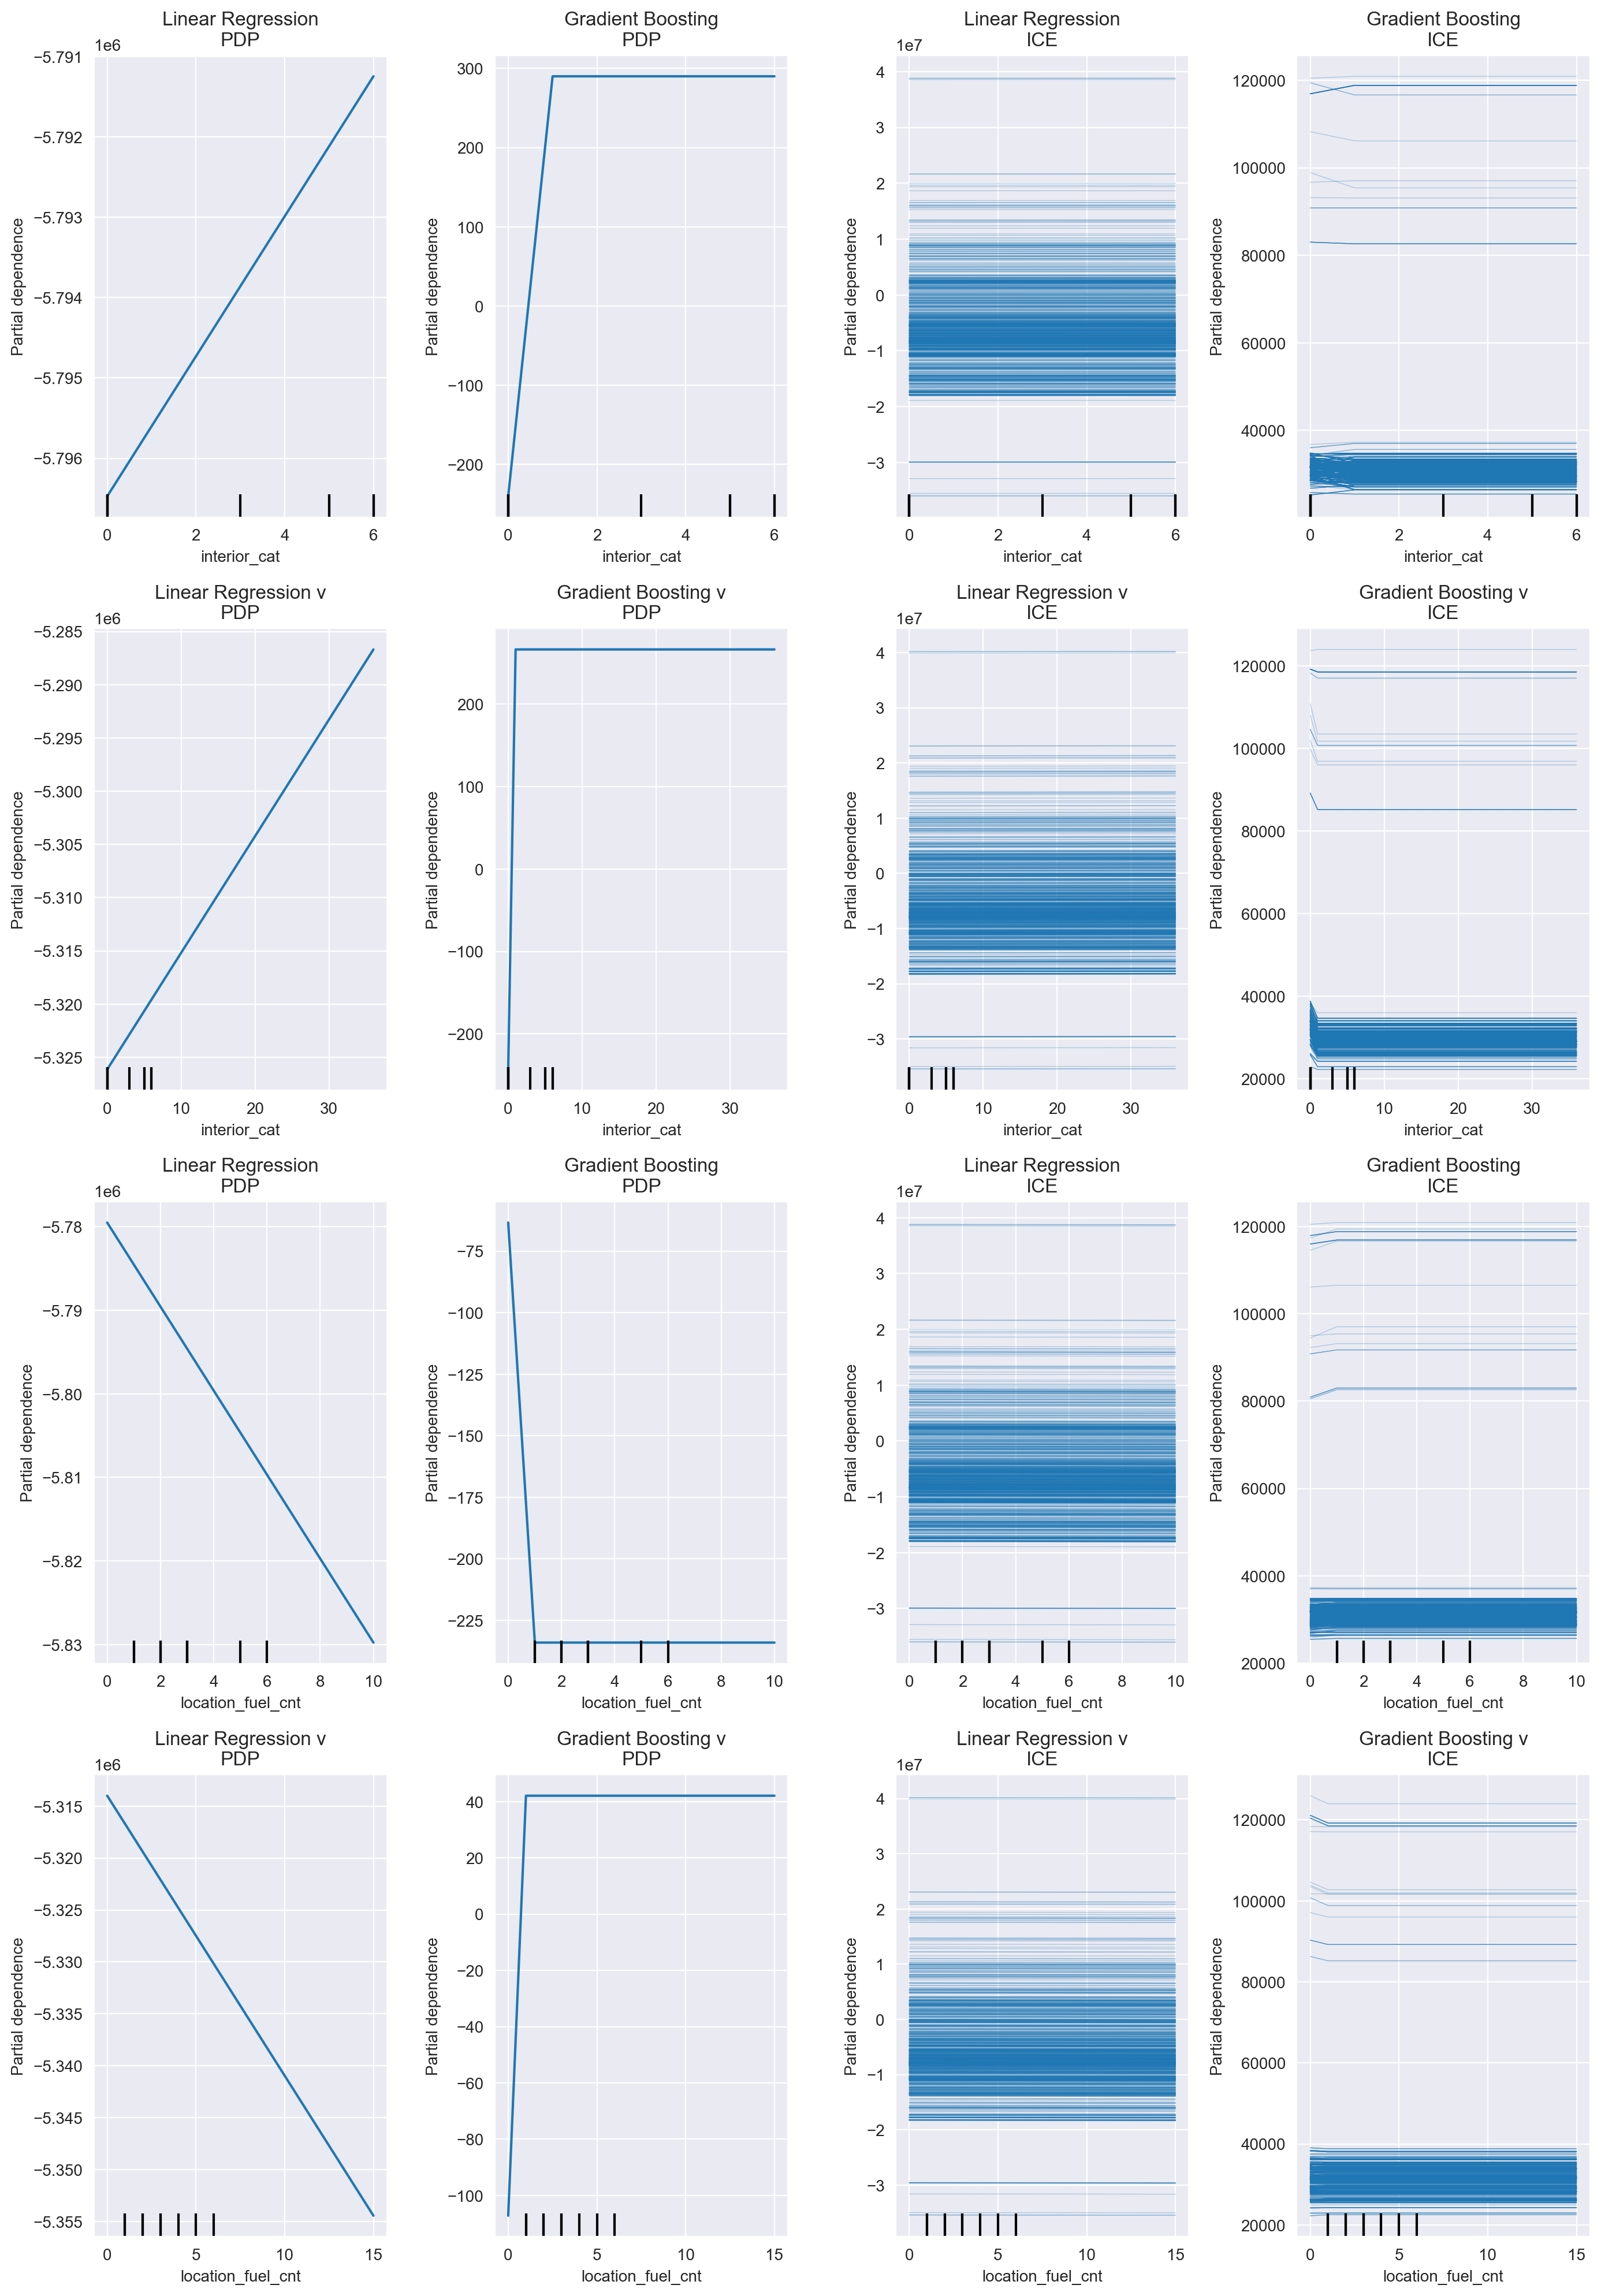

In [10]:
c_feature = ['interior_cat']
fig, axes = plt.subplots(4, 4, figsize=(14, 20))
PartialDependenceDisplay.from_estimator(
    lin_model,
    X_train,
    features=c_feature,
    kind='average',
    grid_resolution=50,
    ax=axes[0, 0],
    random_state=42
)
axes[0, 0].set_title('Linear Regression\nPDP')

PartialDependenceDisplay.from_estimator(
    booster,
    X_train,
    features=c_feature,
    kind='average',
    grid_resolution=50,
    ax=axes[0, 1],
    random_state=42
)
axes[0, 1].set_title('Gradient Boosting\nPDP')

PartialDependenceDisplay.from_estimator(
    lin_model,
    X_train,
    features=c_feature,
    kind='individual',
    grid_resolution=50,
    ax=axes[0, 2],
    random_state=42
)
axes[0, 2].set_title('Linear Regression\nICE')

PartialDependenceDisplay.from_estimator(
    booster,
    X_train,
    features=c_feature,
    kind='individual',
    grid_resolution=50,
    ax=axes[0, 3],
    random_state=42
)
axes[0, 3].set_title('Gradient Boosting\nICE')

PartialDependenceDisplay.from_estimator(
    lin_model_v,
    X_vibros,
    features=c_feature,
    kind='average',
    grid_resolution=50,
    ax=axes[1, 0],
    random_state=42
)
axes[1, 0].set_title('Linear Regression v\nPDP')

PartialDependenceDisplay.from_estimator(
    booster_v,
    X_vibros,
    features=c_feature,
    kind='average',
    grid_resolution=50,
    ax=axes[1, 1],
    random_state=42
)
axes[1, 1].set_title('Gradient Boosting v\nPDP')

PartialDependenceDisplay.from_estimator(
    lin_model_v,
    X_vibros,
    features=c_feature,
    kind='individual',
    grid_resolution=50,
    ax=axes[1, 2],
    random_state=42
)
axes[1, 2].set_title('Linear Regression v\nICE')

PartialDependenceDisplay.from_estimator(
    booster_v,
    X_vibros,
    features=c_feature,
    kind='individual',
    grid_resolution=50,
    ax=axes[1, 3],
    random_state=42
)
axes[1, 3].set_title('Gradient Boosting v\nICE')

c_feature = ['location_fuel_cnt']
PartialDependenceDisplay.from_estimator(
    lin_model,
    X_train,
    features=c_feature,
    kind='average',
    grid_resolution=50,
    ax=axes[2, 0],
    random_state=42
)
axes[2, 0].set_title('Linear Regression\nPDP')

PartialDependenceDisplay.from_estimator(
    booster,
    X_train,
    features=c_feature,
    kind='average',
    grid_resolution=50,
    ax=axes[2, 1],
    random_state=42
)
axes[2, 1].set_title('Gradient Boosting\nPDP')

PartialDependenceDisplay.from_estimator(
    lin_model,
    X_train,
    features=c_feature,
    kind='individual',
    grid_resolution=50,
    ax=axes[2, 2],
    random_state=42
)
axes[2, 2].set_title('Linear Regression\nICE')

PartialDependenceDisplay.from_estimator(
    booster,
    X_train,
    features=c_feature,
    kind='individual',
    grid_resolution=50,
    ax=axes[2, 3],
    random_state=42
)
axes[2, 3].set_title('Gradient Boosting\nICE')

PartialDependenceDisplay.from_estimator(
    lin_model_v,
    X_vibros,
    features=c_feature,
    kind='average',
    grid_resolution=50,
    ax=axes[3, 0],
    random_state=42
)
axes[3, 0].set_title('Linear Regression v\nPDP')

PartialDependenceDisplay.from_estimator(
    booster_v,
    X_vibros,
    features=c_feature,
    kind='average',
    grid_resolution=50,
    ax=axes[3, 1],
    random_state=42
)
axes[3, 1].set_title('Gradient Boosting v\nPDP')

PartialDependenceDisplay.from_estimator(
    lin_model_v,
    X_vibros,
    features=c_feature,
    kind='individual',
    grid_resolution=50,
    ax=axes[3, 2],
    random_state=42
)
axes[3, 2].set_title('Linear Regression v\nICE')

PartialDependenceDisplay.from_estimator(
    booster_v,
    X_vibros,
    features=c_feature,
    kind='individual',
    grid_resolution=50,
    ax=axes[3, 3],
    random_state=42
)
axes[3, 3].set_title('Gradient Boosting v\nICE')

plt.tight_layout()
plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

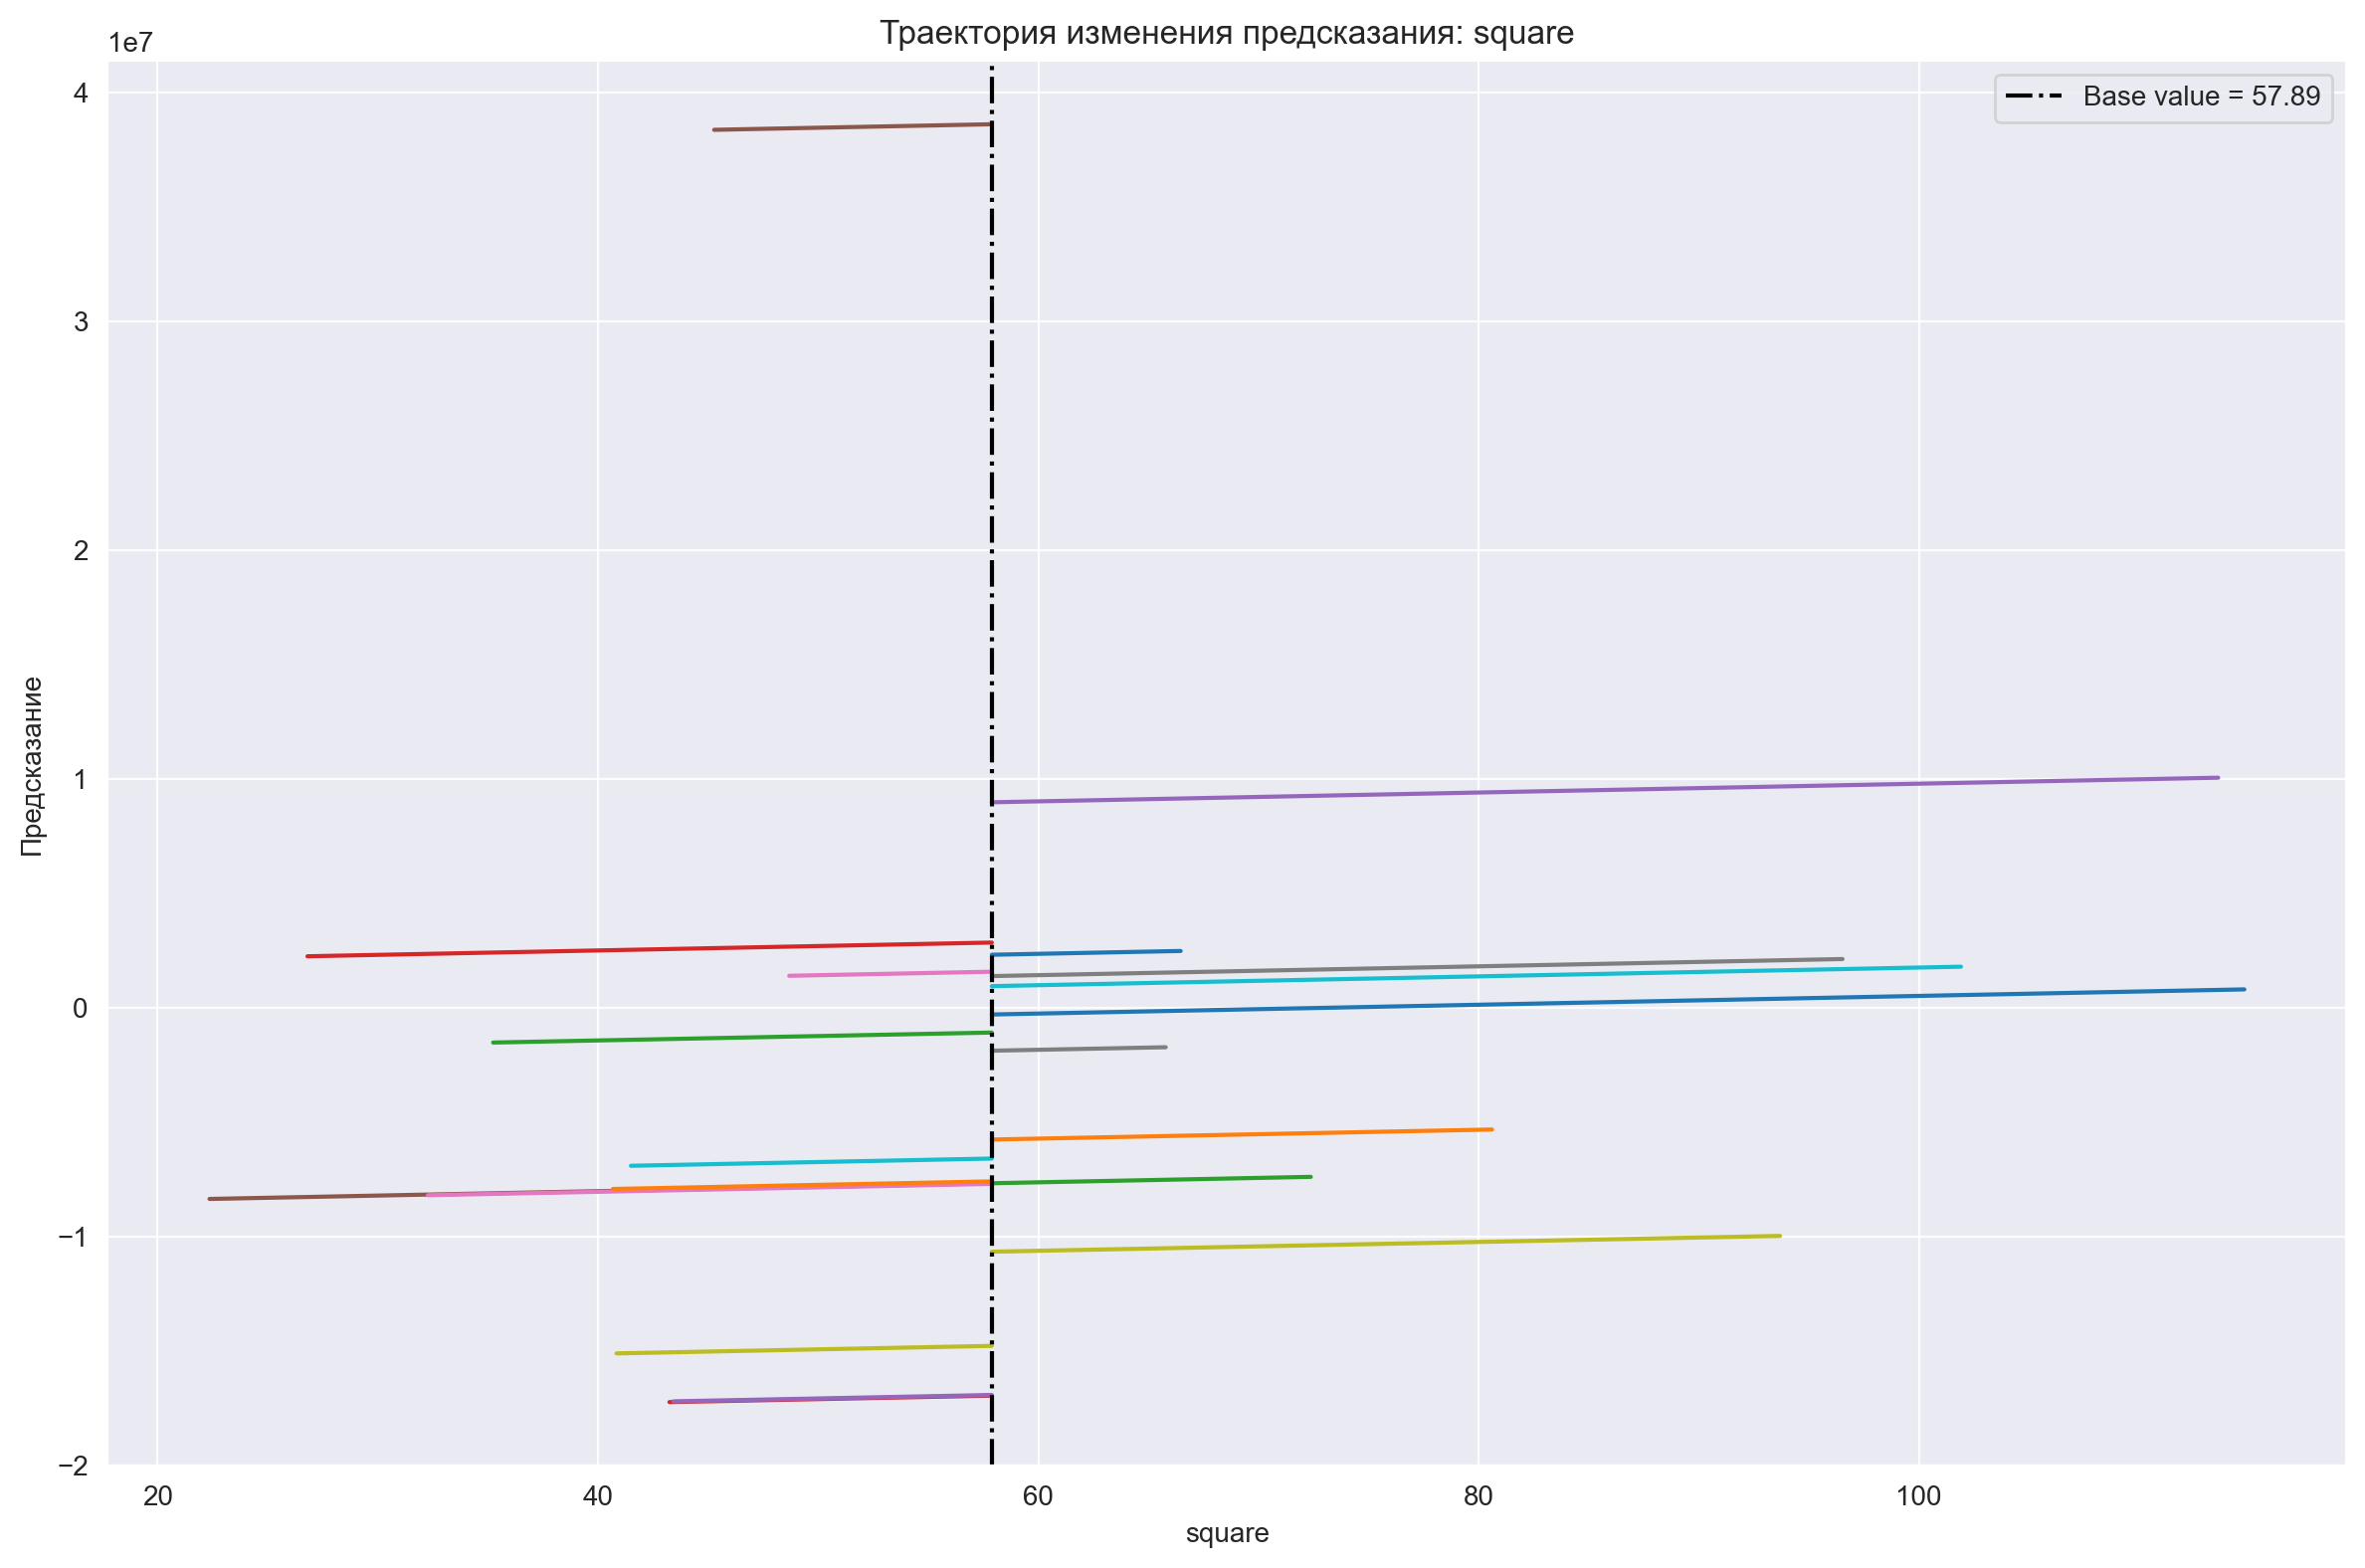

In [11]:
t_col = 'square'
base_value = X_test[t_col].mean()
indeces = np.random.choice(len(X_test), size=20, replace=False)
X_selected = X_test.iloc[indeces].copy()

plt.figure(figsize=(12, 8))
for idx, row in X_selected.iterrows():
    cur_value = row[t_col]
    interpolated_values = np.linspace(cur_value, base_value, 50)
    
    predictions = []
    for val in interpolated_values:
        modified_row = row.copy()
        modified_row[t_col] = val
        modified_df = pd.DataFrame([modified_row])
        pred = lin_model.predict(modified_df)[0]
        predictions.append(pred)
    
    plt.plot(interpolated_values, predictions)

plt.axvline(x=base_value, color='black', linestyle='-.', 
                label=f'Base value = {base_value:.2f}')
plt.xlabel(t_col)
plt.ylabel('Предсказание')
plt.title(f'Траектория изменения предсказания: {t_col}')
plt.legend()
plt.grid(True, alpha=0.9)
plt.tight_layout()
plt.show()

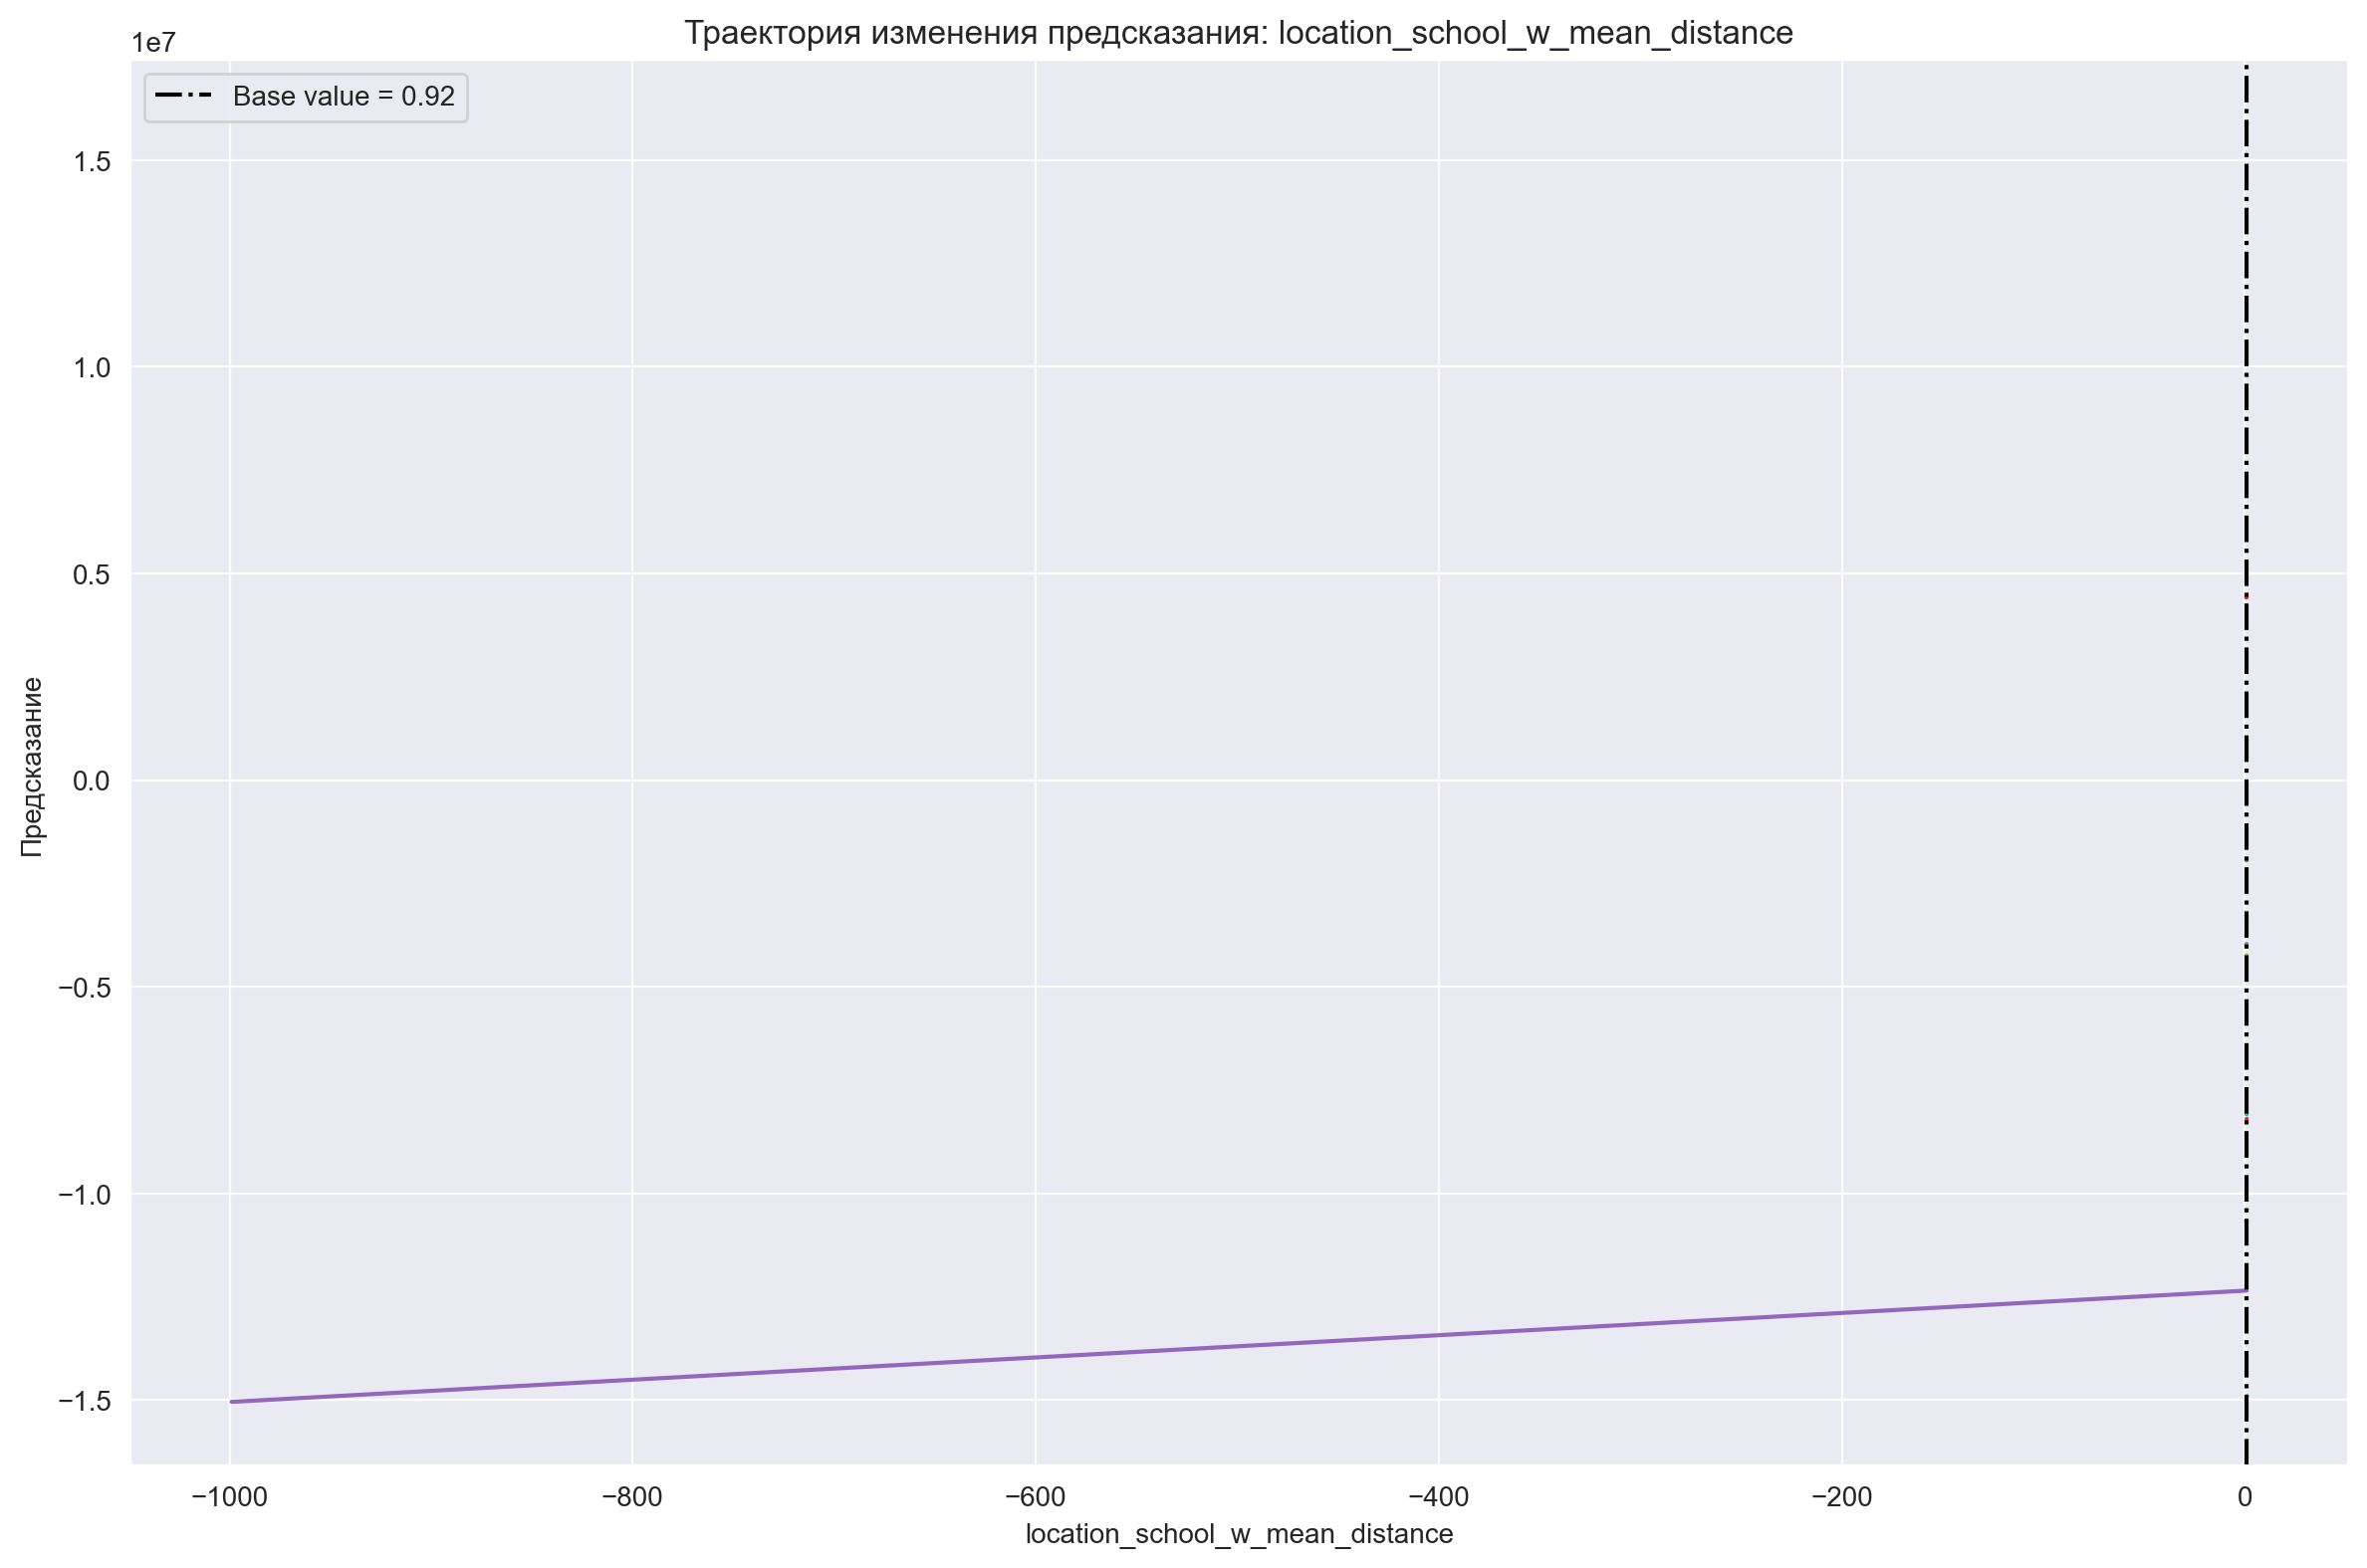

In [12]:
t_col = 'location_school_w_mean_distance'
base_value = X_test[t_col].median()
indeces = np.random.choice(len(X_test), size=20, replace=False)
X_selected = X_test.iloc[indeces].copy()

plt.figure(figsize=(12, 8))
for idx, row in X_selected.iterrows():
    cur_value = row[t_col]
    interpolated_values = np.linspace(cur_value, base_value, 50)
    
    predictions = []
    for val in interpolated_values:
        modified_row = row.copy()
        modified_row[t_col] = val
        modified_df = pd.DataFrame([modified_row])
        pred = lin_model.predict(modified_df)[0]
        predictions.append(pred)
    
    plt.plot(interpolated_values, predictions)

plt.axvline(x=base_value, color='black', linestyle='-.', 
                label=f'Base value = {base_value:.2f}')
plt.xlabel(t_col)
plt.ylabel('Предсказание')
plt.title(f'Траектория изменения предсказания: {t_col}')
plt.legend()
plt.grid(True, alpha=0.9)
plt.tight_layout()
plt.show()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


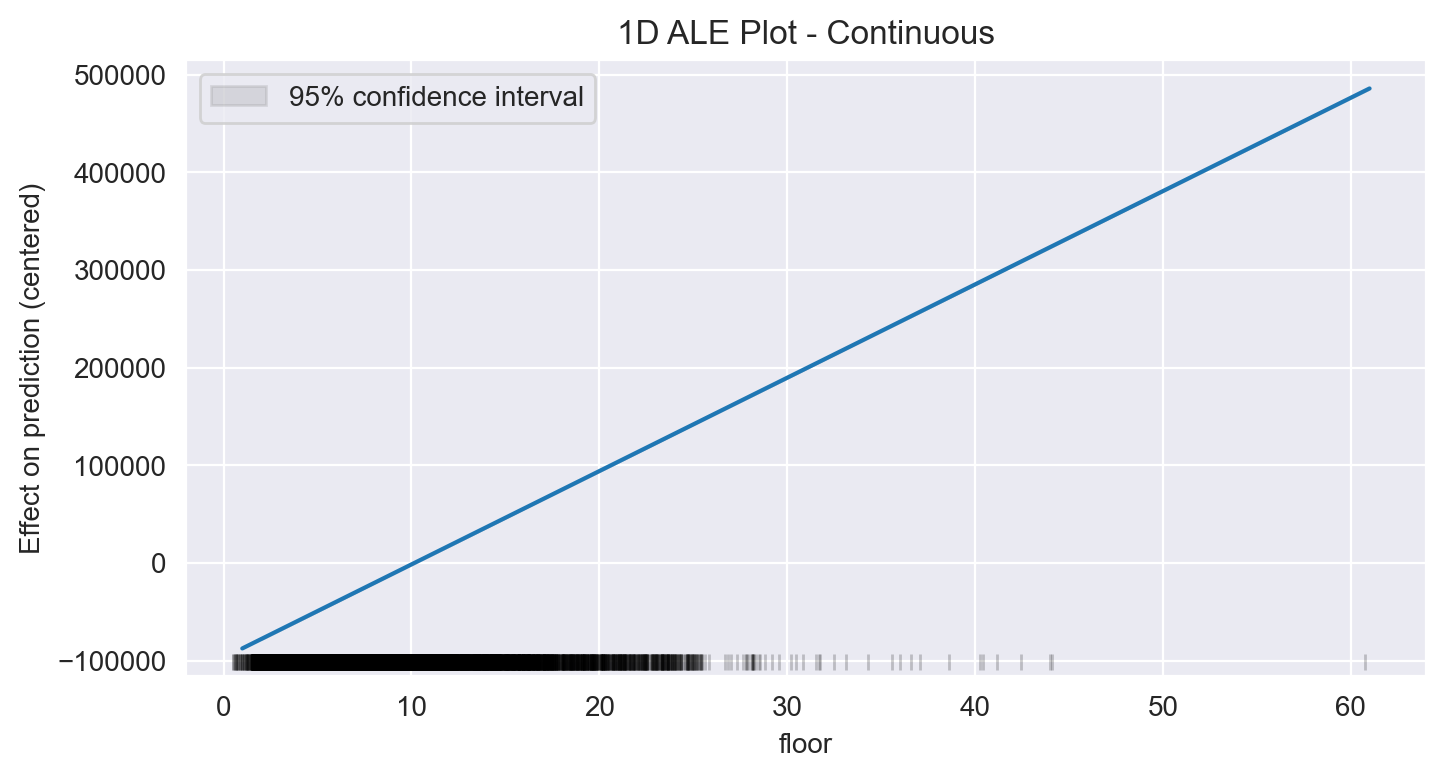

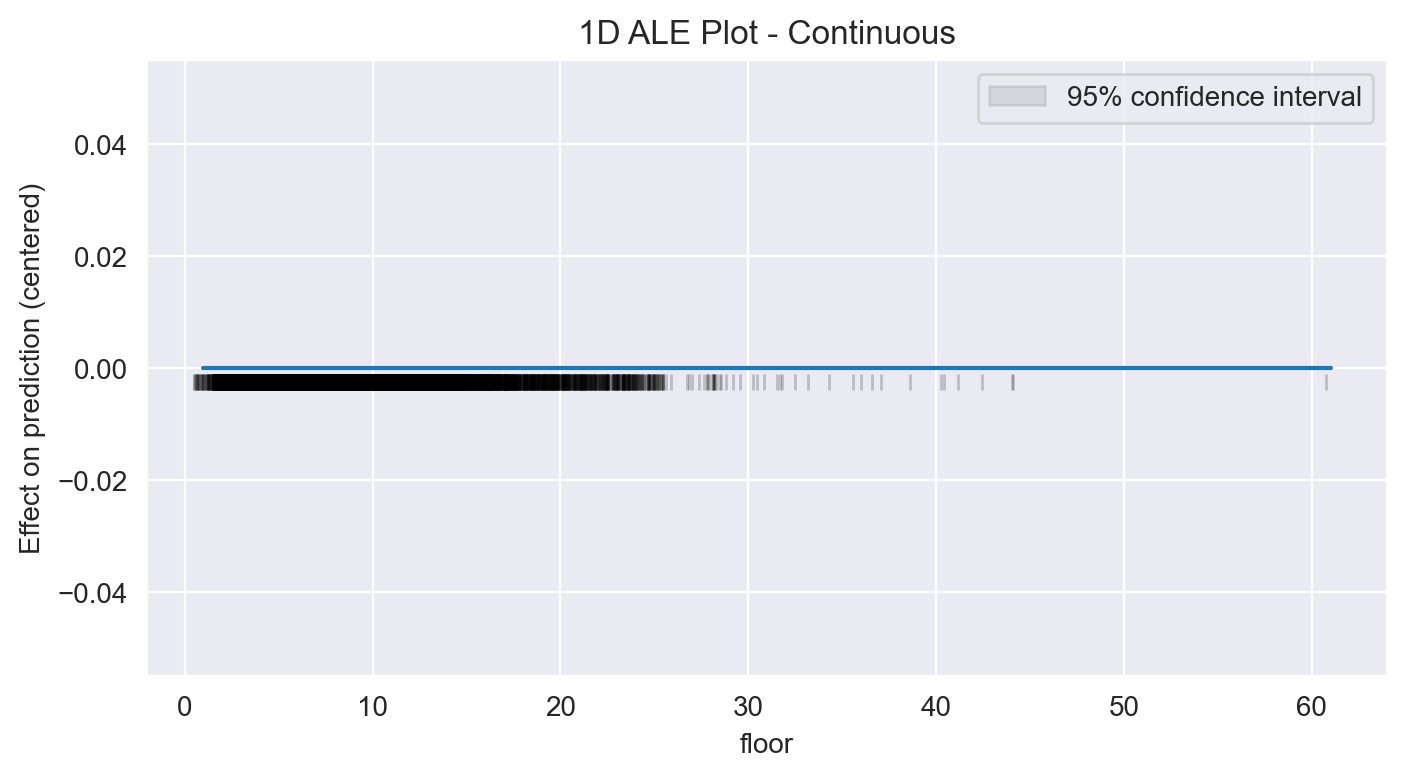

In [13]:
ale_lr = PyALE.ale(
    X=X_test,           
    model=lin_model,            
    feature=['floor'],   
    grid_size=20,               
    include_CI=True,            
    C=0.95                      
)

# Для бустинга
ale_gb = PyALE.ale(
    X=X_test,
    model=booster,
    feature=['floor'],
    grid_size=20,
    include_CI=True,
    C=0.95
)

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



In [16]:
predictions_lm_noper = lin_model.predict(X_train_mm)
predictions_gb_noper = booster.predict(X_train_mm)

print(f"Р-квадрат для базовых моделей: {r2_score(y_train, predictions_lm_noper):.4f} - LR, {r2_score(y_train, predictions_gb_noper):.4f} - GB")
print(f"MAPE для базовых моделей: {mean_absolute_percentage_error(y_train, predictions_lm_noper):.3f} - LR, {mean_absolute_percentage_error(y_train, predictions_gb_noper):.3f} - GB")

Р-квадрат для базовых моделей: 0.8180 - LR, 0.9770 - GB
MAPE для базовых моделей: 0.097 - LR, 0.040 - GB


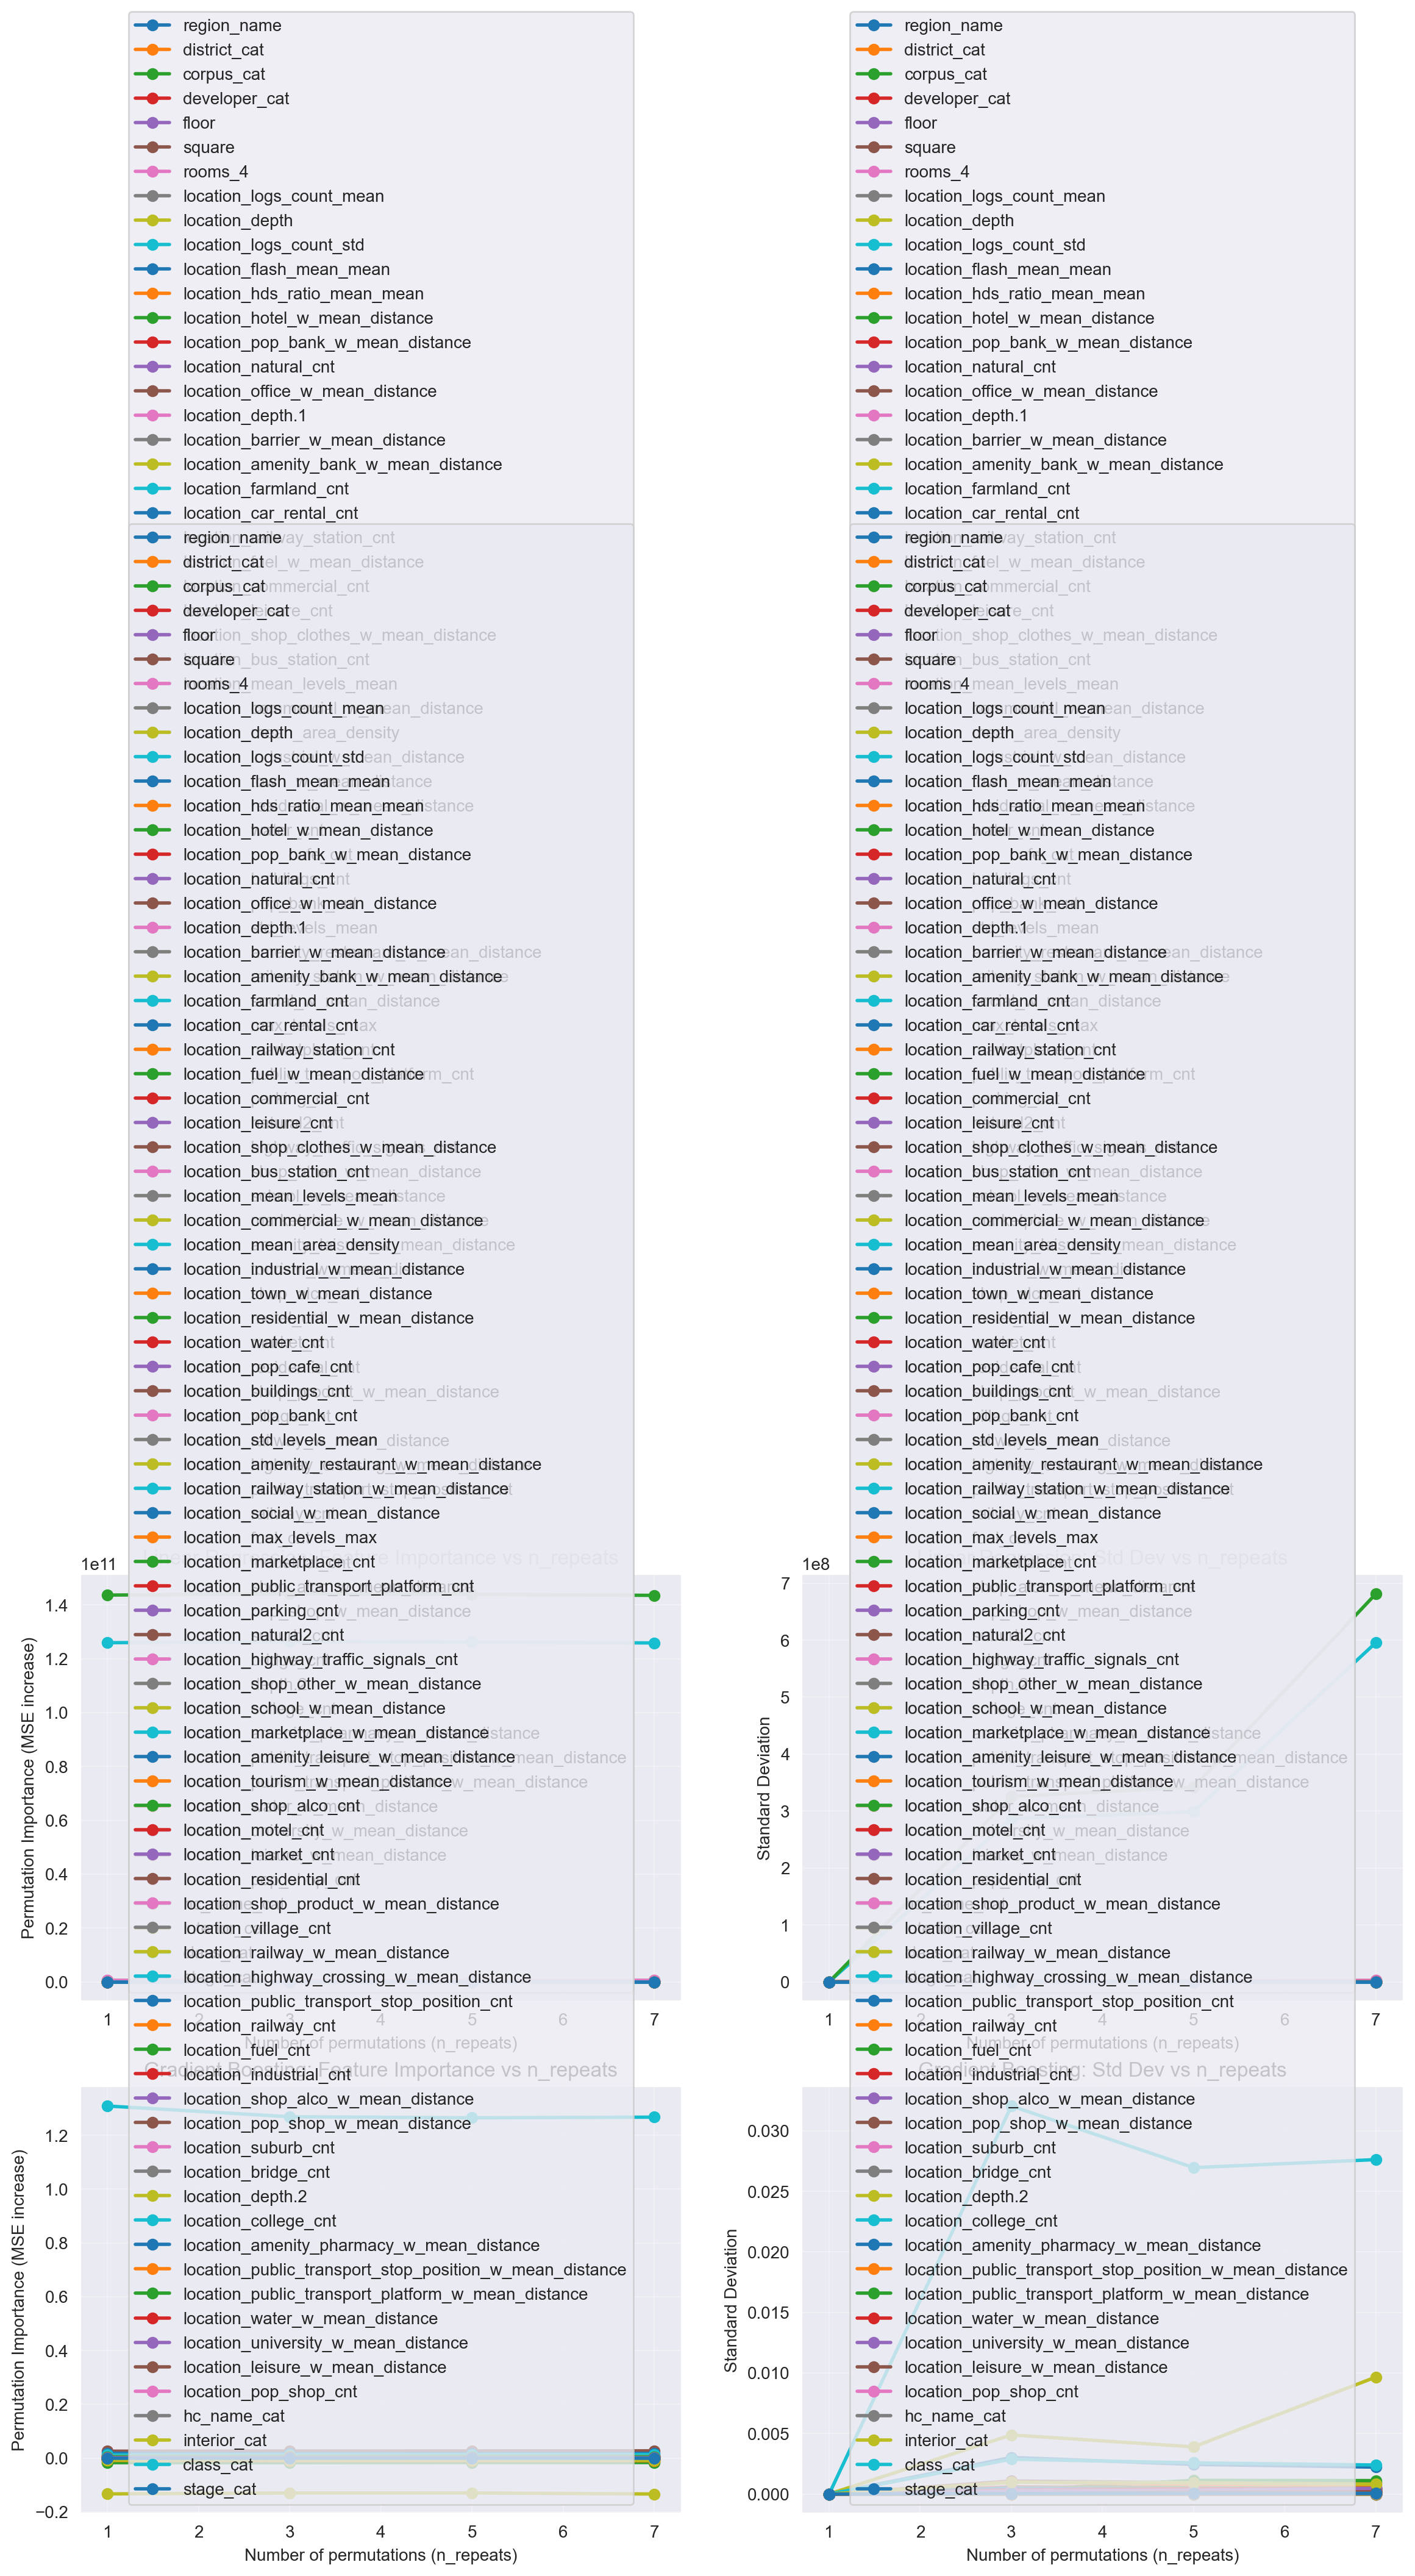

In [21]:
lm_imps = {}
gb_imps = {}
lm_std = {}
gb_std = {}
repeats = [1, 3, 5, 7]
for rep_num in repeats:
    lm_result = permutation_importance(lin_model, X_train, predictions_lm_noper, random_state=42, n_repeats=rep_num, scoring='r2')
    lm_imps[rep_num] = lm_result.importances_mean
    lm_std[rep_num] = lm_result.importances_std
    
    gb_result = permutation_importance(booster, X_train, predictions_gb_noper, random_state=42, n_repeats=rep_num, scoring='r2')
    gb_imps[rep_num] = gb_result.importances_mean
    gb_std[rep_num] = gb_result.importances_std
    
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

feature_names = X.columns.tolist()

ax = axes[0, 0]
for idx, name in enumerate(feature_names):
    values = [lm_imps[n][idx] for n in repeats]
    ax.plot(repeats, values, 'o-', label=name, linewidth=2, markersize=6)
ax.set_xlabel('Number of permutations (n_repeats)')
ax.set_ylabel('Permutation Importance (MSE increase)')
ax.set_title('Linear Regression: Feature Importance vs n_repeats')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for idx, name in enumerate(feature_names):
    std_values = [lm_std[n][idx] for n in repeats]
    ax.plot(repeats, std_values, 'o-', label=name, linewidth=2, markersize=6)
ax.set_xlabel('Number of permutations (n_repeats)')
ax.set_ylabel('Standard Deviation')
ax.set_title('Linear Regression: Std Dev vs n_repeats')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for idx, name in enumerate(feature_names):
    values = [gb_imps[n][idx] for n in repeats]
    ax.plot(repeats, values, 'o-', label=name, linewidth=2, markersize=6)
ax.set_xlabel('Number of permutations (n_repeats)')
ax.set_ylabel('Permutation Importance (MSE increase)')
ax.set_title('Gradient Boosting: Feature Importance vs n_repeats')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for idx, name in enumerate(feature_names):
    std_values = [gb_std[n][idx] for n in repeats]
    ax.plot(repeats, std_values, 'o-', label=name, linewidth=2, markersize=6)
ax.set_xlabel('Number of permutations (n_repeats)')
ax.set_ylabel('Standard Deviation')
ax.set_title('Gradient Boosting: Std Dev vs n_repeats')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 
